# Trabajo Semanal 4
### Joaquin Ezequiel Alvarez Olmedo

El trabajo semanal 4 consiste en diseñar un filtro pasabanda según la siguiente plantilla:

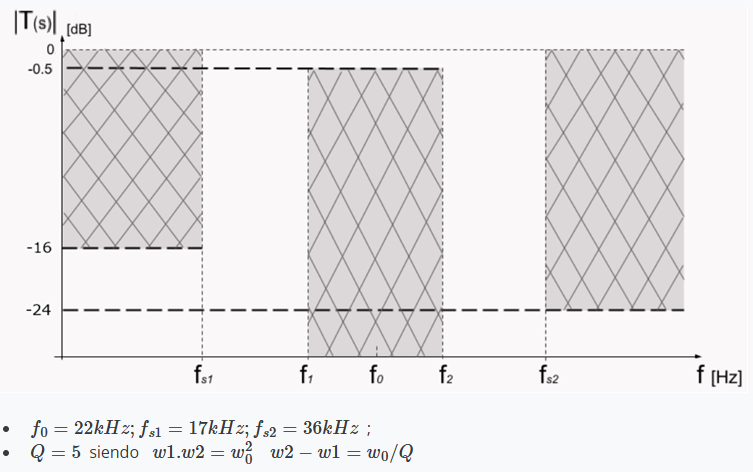

Comenzamos obteniendo las cotas del ancho de banda mediante las siguientes propiedades del pasa banda: 

1) $ B_w = w_p2 - w_p1 = \frac{w_0}{Q} = \frac{44\pi*10^{3}}{5} = 27646 \frac{rad}{seg} $
   
2) $ w_0^{2} = w_p1 * w_p2 = 19.1 * 10^{9} (\frac{rad}{seg})^{2} $

Resolvemos el sistema de ecuaciones:

$ w_p2 = 27646 + w_p1 $

$ w_p1 * (w_p1 + 27646) = 19.1 * 10^{9} $

$ w_p1^{2} + 27646 * w_p1 - 19.1 * 10^{9} = 0 $

Resolvemos el polinomio de grado 2, descartamos la raiz negativa y nos queda $ w_p1 = 125069 \frac{rad}{seg} $ y $ w_p2 = 152715 \frac{rad}{seg} $ 

Normalizamos las frecuencias de paso y de corte según $ w_0 = 44\pi*10^{3} $:

$ w_p1 = 0.905 $, $ w_p2 = 1.105 $

$ w_s1 = 0.773 $, $ w_s2 = 1.636 $

Aplicamos transformación en frecuencia ($ \Omega = Q\frac{w^{2} - 1}{w} $) para obtener frecuencias de paso y de corte de nuestro filtro prototipo pasabajos:

$ \Omega_p1 = 5 * \frac{0.905^{2} - 1}{0.905} = -0.99 \cong -1 $

$ \Omega_p2 = 5 * \frac{1.105^{2} - 1}{1.105} = 0.99 \cong 1 $

$ w_p1 $ y $ w_p2 $ se convierten en una $ \Omega_p = 1 $

$ \Omega_s1 = 5 * \frac{0.773^{2} - 1}{0.773} = -2.6 $

$ \Omega_s2 = 5 * \frac{1.636^{2} - 1}{1.636} = 5.127 $

$ w_p1 $ y $ w_p2 $ se convierten en $ \Omega_s1 = 2.6 $, $ \Omega_s2 = 5.127 $

Tenemos los datos necesarios para calcular n y $ \xi^{2} $. Al tener 2 $ \alpha min $, habra que hacer los calculos para cada uno. Debemos quedarnos con el n mas grande para cumplir con la atenuación requerida:

$ \xi^{2} = 10^{\frac{0.5}{10}} - 1 = 0.122 $

$ \alpha_1 min = 10 * \log(\xi^{2} * \cosh^{2}(n * \cosh^{-1}(\Omega_s1))) = 10 * \log(0.122 * \cosh^{2}(1.609 * n)) $

$ 18.064 = \cosh(1.609 * n) $

$ n = 2.23 \cong 3 $

Ahora con $ \alpha_2 min $:

$ \alpha_2 min = 10 * \log(\xi^{2} * \cosh^{2}(n * \cosh^{-1}(\Omega_s2))) = 10 * \log(0.122 * \cosh^{2}(2.318 * n)) $

$ 45.375 = \cosh(2.318 * n) $

$ n = 1.945 \cong 2 $

Nuestro filtro prototipo pasabajos será de orden 3. Recurrimos a la simulación para obtener la transferencia:

#### Chebyshev1_ord_3_rip_0.5_att_16

<IPython.core.display.Math object>

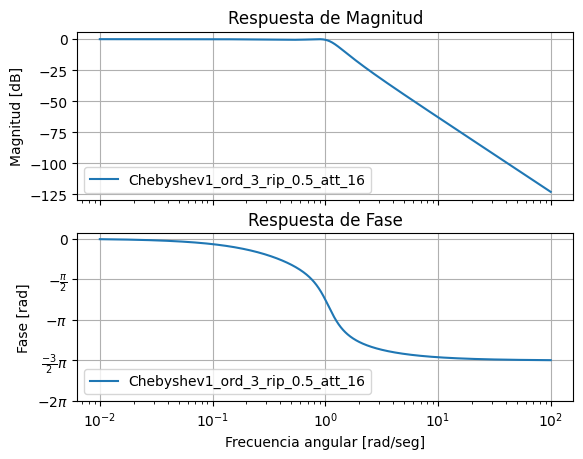

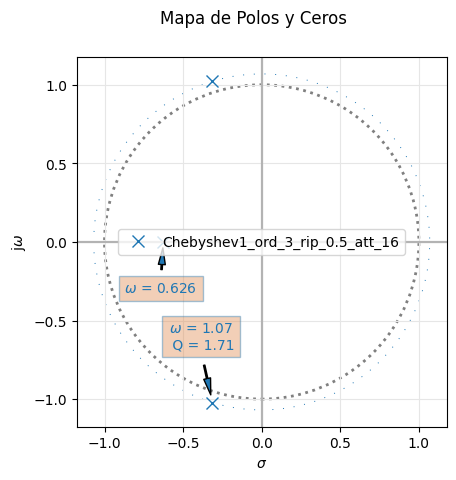

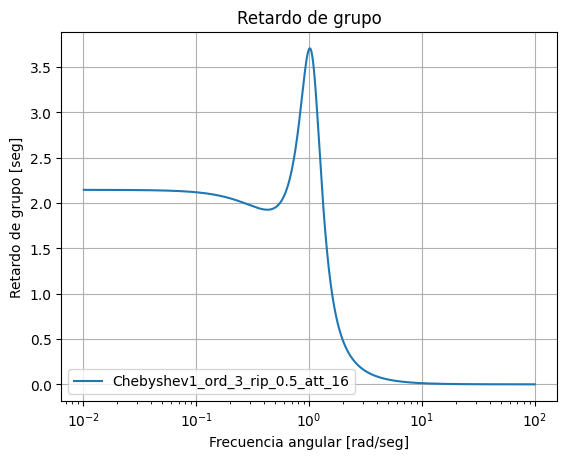

In [8]:
#%% Importamos librerias

import numpy as np
import sympy as sp
import scipy.signal as sig
from pytc2.sistemas_lineales import analyze_sys, parametrize_sos, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS, pretty_print_lti, tf2sos_analog
from pytc2.general import print_subtitle


#%% Funcion que devuelve la transferecia segun el orden, alfa min, alfa max y la aproximacion indicada

def sim_aprox(aproxs, orders2analyze, ripple, attenuation):

    all_sys = []
    filter_names = []

    for (this_aprox, this_order, this_ripple, this_att) in zip(aproxs, orders2analyze, ripple, attenuation):

        if this_aprox == 'Butterworth':

            z,p,k = sig.buttap(this_order)

            eps = np.sqrt( 10**(this_ripple/10) - 1 )
            num, den = sig.zpk2tf(z,p,k)
            num, den = sig.lp2lp(num, den, eps**(-1/this_order))

            z,p,k = sig.tf2zpk(num, den)

        elif this_aprox == 'Chebyshev1':

            z,p,k = sig.cheb1ap(this_order, this_ripple)

        elif this_aprox == 'Chebyshev2':

            z,p,k = sig.cheb2ap(this_order, this_att)

        elif this_aprox == 'Bessel':

            z,p,k = sig.besselap(this_order, norm='delay')

        elif this_aprox == 'Cauer':

            z,p,k = sig.ellipap(this_order, this_ripple, this_att)


        num, den = sig.zpk2tf(z,p,k)

        
        all_sys.append(sig.TransferFunction(num,den))

        this_label = this_aprox + '_ord_' + str(this_order) + '_rip_' + str(this_ripple)+ '_att_' + str(this_att)
        
        print_subtitle(this_label)
        # factorizamos en SOS's
        this_sos = tf2sos_analog(num, den)
        
        pretty_print_SOS(this_sos, mode='omegayq')
        
        filter_names.append(this_label)
        
    # el caracter "_" descarta la salida de la función
    _ = analyze_sys( all_sys, filter_names )

    return( all_sys, filter_names )


#%% Determinamos los parametros que le tenemos que otorgar a la funcion

#aprox_name = 'Butterworth'
aprox_name = 'Chebyshev1'
#aprox_name = 'Chebyshev2'
#aprox_name = 'Bessel'
#aprox_name = 'Cauer'

orders2analyze = [3] # Orden del filtro

aproxs = [aprox_name] * len(orders2analyze)
ripple = [0.5] * len(orders2analyze) # Alfa max
attenuation = [16] * len(orders2analyze) # Alfa min

( all_sys, filter_names ) = sim_aprox(aproxs, orders2analyze, ripple, attenuation)

Ahora aplicamos el núcleo de transformación en frecuencia normalizado $ (K(S) = Q\frac{S^{2} + 1}{S}) $ a ambas secciones. Comenzamos con la FOS:

$ T_1(S) = \frac{1}{Q\frac{S^{2} + 1}{S} + 1} = \frac{1}{SQ + 1 + \frac{Q}{S}} = \frac{S\frac{1}{Q}}{S^{2} + S\frac{1}{Q} + 1} $

$ T_1(S) = \frac{S\frac{0.6265}{5}}{S^{2} + S\frac{0.6265}{5} + 0.6265^{2}} $ con $ w_01 = 0.6265 $, $ Q_1 = 5 $, $ K_1 = 1 $

Transformamos la SOS normalizada:

$ T_2(S) = \frac{1}{(Q\frac{S^{2} + 1}{S})^{2} + \frac{Q}{q}\frac{S^{2} + 1}{S} + 1} = \frac{S^{\frac{1}{Q}} * S^{\frac{1}{Q}}}{S^{4} + S^{3}\frac{1}{Qq} + S^{2}(2 + \frac{1}{Q^{2}}) + S\frac{1}{Qq} + 1} $

A partir de ahora recurrimos a la simulación para factorizar la transferencia. De paso verificamos $ T_1(S) $:

<IPython.core.display.Math object>

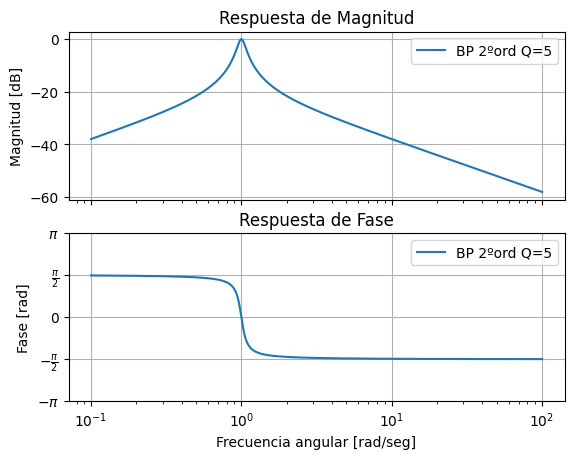

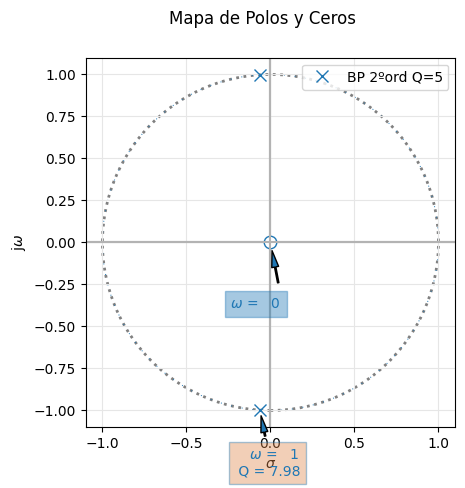

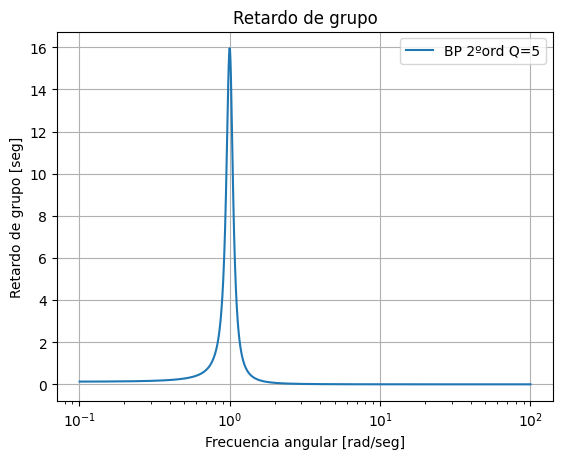

In [9]:
# Coeficientes de la transferencia de primer orden T1
w0 = 0.6265

T1_num = np.array([w0])
T1_den = np.array([1, w0])

# Q de la transformación
Q_bp = 5

# Núcleo LP-BP
num_pbanda, den_pbanda = sig.lp2bp(T1_num, T1_den, bw = 1/Q_bp)

T1_bp = sig.TransferFunction(num_pbanda, den_pbanda)

pretty_print_lti(num_pbanda, den_pbanda)

_= analyze_sys([T1_bp], sys_name='BP 2ºord Q={:d}'.format(Q_bp))

$ \frac{0.6265}{5} = 0.1253 $, la transferencia simulada respalda lo calculado.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

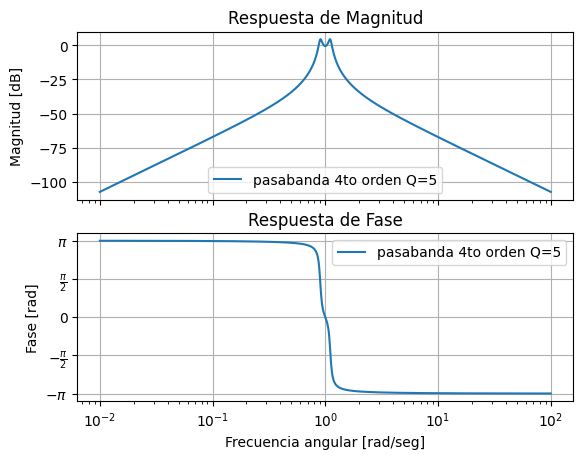

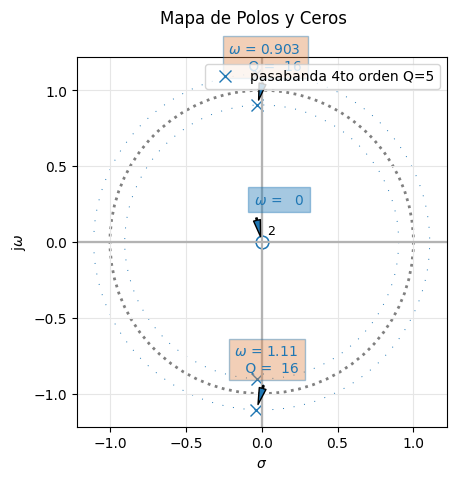

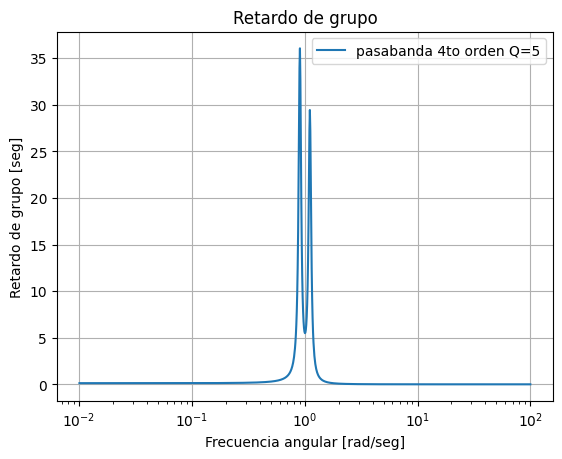

In [10]:
# Armamos la transferencia
w0 = 1.069
qq = 1.706

T2_num = np.array([w0])
T2_den = np.array([1, w0/qq, w0**2])

# Q de la transformación
Q_bp = 5

# Núcleo LP-BP
num_pbanda, den_pbanda = sig.lp2bp(T2_num, T2_den, bw = 1/Q_bp)

sos_pbanda = tf2sos_analog(num_pbanda, den_pbanda)

T2_bp =  sig.TransferFunction(num_pbanda, den_pbanda)

pretty_print_lti(T2_bp)

sos_pb = tf2sos_analog(num_pbanda, den_pbanda)
pretty_print_SOS(sos_pb)

_ = analyze_sys(T2_bp, sys_name='pasabanda 4to orden Q={:d}'.format(Q_bp))

En resumen las SOS obtenidas son las siguientes:

$ T_1(S) = \frac{S\frac{0.6265}{5}}{S^{2} + S\frac{0.6265}{5} + 0.6265^{2}} $ con $ w_01 = 0.6265 $, $ Q_1 = 5 $, $ K_1 = 1 $

$ T_2(S) = \frac{S\frac{0.903}{16.04} * 2.77}{S^{2} + S\frac{0.903}{16.04} + 0.903^{2}} $ con $ w_02 = 0.903 $, $ Q_2 = 16.04 $, $ K_2 = 2.77 $

$ T_3(S) = \frac{S\frac{1.107}{16.04} * 3.97}{S^{2} + S\frac{1.107}{16.04} + 1.107^{2}} $ con $ w_03 = 1.107 $, $ Q_3 = 16.04 $, $ K_3 = 3.97 $

Vemos que de la transformación del prototipo pasabajos de segundo orden obtuvimos 2 SOS pasabanda con $ Q_2 = Q_3 $ y $ w_02 = \frac{1}{w0_3}$

Ahora armamos las secciones mediante circuitos pasivos. Proponemos el siguiente RLC pasabanda:

$ T_bp(S) = \frac{R}{SL + R + \frac{1}{SC}} = \frac{SCR}{S^{2}LC + SCR + 1} = \frac{S\frac{R}{L}}{S^{2} + S\frac{R}{L} + \frac{1}{LC}} $ donde $ w_0^{2} = \frac{1}{LC} $ y $ \frac{w_0}{Q} = \frac{R}{L} $

Normalizamos $ \Omega_w = w_0 $ y obtenemos $ L = \frac{1}{C} = QR $

Normalizamos $ Z_R = R $ y obtenemos $ L = Q $, $ C = \frac{1}{Q} $

Con estos parametros tenemos armadas las SOS, conectadas entre si mediante buffers. El problema con el que nos encontramos es que circuitos pasivos como estos no tienen ganancia y necesitamos generar un K en algún lugar del circuito para compensar esta deficiencia. Proponemos colocar un OP-AMP en configuracion no inversora preferiblemente al comienzo del circuito:

Sabemos que la ganancia del no inversor es de $ 1 + \frac{R_2}{R_1} $

Englobamos todos los K de las SOS en una sola y buscamos una relación entre R1 y R2 que se ajuste al K total:

$ K_t = K_1 * K_2 * K_3 = 1 * 2.77 * 3.97 \cong 11 $

$ 1 + \frac{R_2}{R_1} = K_t $

$ R_2 = 10R_1 $

Podemos hacer que R1 cumpla con la norma de impedancia propuesta previamente y tendriamos $ R_1 = 1 $, $ R_2 = 10 $

A continuación simulamos el circuito en Spice:

**INSERTAR ESQUEMATICO DEL CIRCUITO EN SPICE + RESPUESTA EN FRECUENCIA**